# xrt_toolkit tutorial

The library computes X-ray transforms on a GPU: the **forward** operator
integrates an image along rays, the **adjoint** (its exact transpose) spreads
ray values back into the image. Everything else — geometries, basis orders,
reconstruction, differentiation — is built around this pair.

A CUDA GPU is required.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import drjit as dr
from drjit.cuda.ad import Array2f, Float

import xrt_toolkit as xtk

# problem size: change these to explore other scan configurations
N = 128            # image is N x N
N_angles = 180     # projection angles (parallel scan; the cone scan uses 2x)
N_detectors = 192  # detector cells

# test image: an ellipse with two inserts, on a lattice centered at the origin
yy, xx = np.mgrid[:N, :N]
img = ((((xx - 64) / 40) ** 2 + ((yy - 64) / 52) ** 2) < 1).astype(np.float32)
img -= 0.5 * ((((xx - 52) / 12) ** 2 + ((yy - 56) / 18) ** 2) < 1)
img += 0.7 * ((((xx - 82) / 9) ** 2 + ((yy - 74) / 9) ** 2) < 1)
f = Float(img.reshape(-1))

knot = xtk.UniformSpec(start=(-N / 2 + 0.5,) * 2, step=1, num=(N, N))

## Arbitrary geometry

A geometry is any set of rays, each given by a point `t` and a direction `n`.
Three rays are enough to start; `plot_rays` shows them inside the volume, and
`xrt_apply(rays, knot, order, f)` returns one line integral per ray.

line integrals of the 3 rays: [103.    76.25  65.  ]


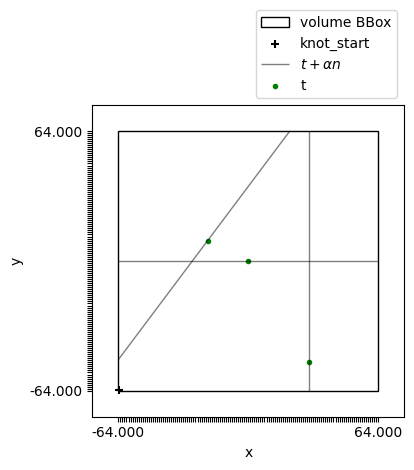

In [2]:
t = Array2f([0.0, -20.0, 30.0], [0.0, 10.0, -50.0])
n = Array2f([1.0, 0.6, 0.0], [0.0, 0.8, 1.0])
rays3 = (t, n)

xtk.plot_rays(rays3, knot)
y3 = xtk.xrt_apply(rays3, knot, 0, f)
print("line integrals of the 3 rays:", np.asarray(y3))

## Structured geometry

`parallel_beam` and `cone_beam` build standard scans from a list of angles and
a `DetectorSpec`; the matching operators are `xrt_struct_apply` /
`xrt_struct_adjoint`. `order` selects the basis (0 voxels, 1 / 2 box splines).

Text(0.5, 0.98, 'cone_beam')

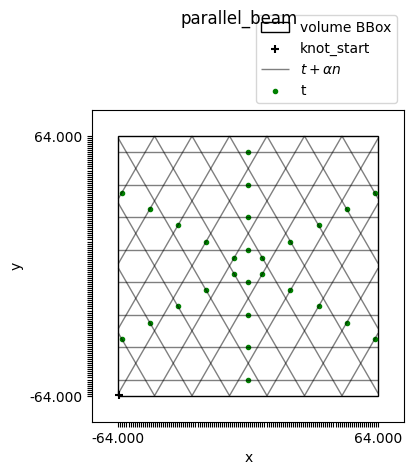

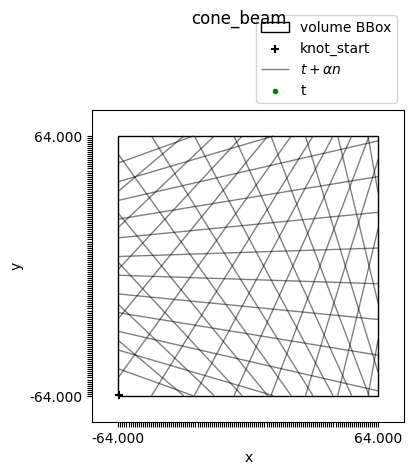

In [3]:
angles = dr.linspace(Float, 0, np.pi, N_angles, endpoint=False)
det = xtk.DetectorSpec(size=(1.5 * N,), num_cell=(N_detectors,))
rays_par = xtk.parallel_beam(angles, det)

angles_cb = dr.linspace(Float, 0, 2 * np.pi, 2 * N_angles, endpoint=False)
sod, sdd = 1.6 * N, 2.8 * N
det_cb = xtk.DetectorSpec(size=(2.2 * N,), num_cell=(N_detectors + 64,))
rays_cone = xtk.cone_beam(sod=sod, sdd=sdd, angles=angles_cb, detector_spec=det_cb)

few = xtk.parallel_beam(dr.linspace(Float, 0, np.pi, 3, endpoint=False),
                        xtk.DetectorSpec(size=(1.5 * N,), num_cell=(12,)))
few_cb = xtk.cone_beam(sod=sod, sdd=sdd,
                       angles=dr.linspace(Float, 0, 2 * np.pi, 3, endpoint=False),
                       detector_spec=xtk.DetectorSpec(size=(2.2 * N,), num_cell=(12,)))
xtk.plot_rays(few, knot).suptitle("parallel_beam")
xtk.plot_rays(few_cb, knot).suptitle("cone_beam")

### Forward: image to sinogram

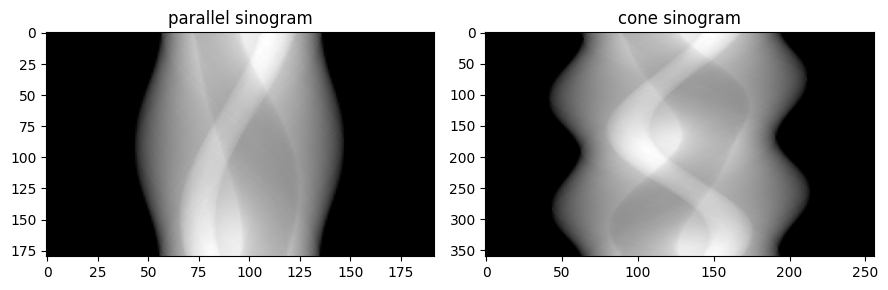

In [4]:
sino_par = xtk.xrt_struct_apply(rays_par, knot, 0, f)    # (N_angles * N_detectors,)
sino_cone = xtk.xrt_struct_apply(rays_cone, knot, 0, f)

fig, axs = plt.subplots(1, 2, figsize=(9, 3))
axs[0].imshow(np.asarray(sino_par).reshape(N_angles, N_detectors),
              cmap="gray", aspect="auto")
axs[0].set_title("parallel sinogram")
axs[1].imshow(np.asarray(sino_cone).reshape(2 * N_angles, N_detectors + 64),
              cmap="gray", aspect="auto")
axs[1].set_title("cone sinogram")
plt.tight_layout()

### Backward: sinogram to image

The adjoint applied to a sinogram gives the (unfiltered) backprojection --
each measurement smeared back along its ray.

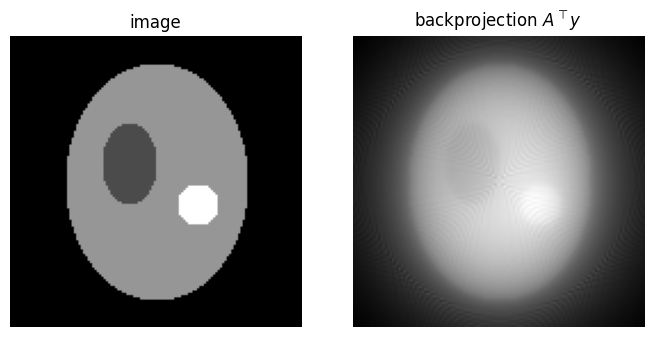

In [5]:
bp = xtk.xrt_struct_adjoint(rays_par, knot, 0, sino_par)

fig, axs = plt.subplots(1, 2, figsize=(7, 3.4))
axs[0].imshow(img, cmap="gray"); axs[0].set_title("image")
axs[1].imshow(np.asarray(bp).reshape(N, N), cmap="gray")
axs[1].set_title(r"backprojection $A^\top y$")
for ax in axs:
    ax.axis("off")
plt.tight_layout()

## Reconstruction

`xrt_toolkit.optim` provides the basics: `cg` and `gd` take the
forward/adjoint pair as callables and work with any geometry; `fbp` (parallel),
`fbp_cone` (cone) and `bpf` (backprojection-then-filtering) are one-call
analytic methods for structured scans.

One performance rule: the structured operators launch one kernel per
projection (fine for a single pass), while the explicit operators trace all
rays in one fused kernel. Inside an iterative solver, expand the scan once
with `struct_rays` and use `xrt_apply` / `xrt_adjoint` — same rays, same
ordering, ~100x faster per iteration.

On this noiseless data the sharp `ramp` window is used and `cg` wins (it
solves the exact discrete system). With noisy data the ranking flips: the
ramp amplifies noise (the default `hann` window is then the better choice)
and `cg` must be stopped early — its error decreases, then turns around.

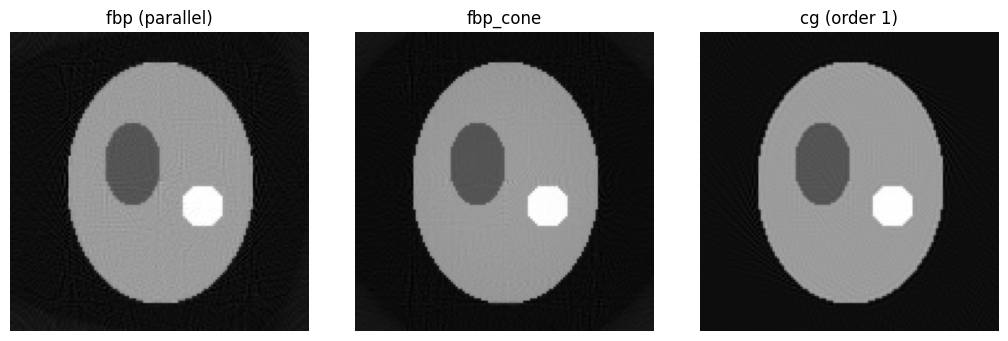

In [6]:
rec_fbp = xtk.fbp(rays_par, knot, sino_par, window="ramp")
rec_cone = xtk.fbp_cone(rays_cone, knot, sino_cone, sod=sod, sdd=sdd, window="ramp")
rays_e = xtk.struct_rays(rays_par)  # explicit rays: fused kernels for iterating
rec_cg = xtk.cg(lambda v: xtk.xrt_apply(rays_e, knot, 1, v),
                lambda v: xtk.xrt_adjoint(rays_e, knot, 1, v),
                xtk.xrt_apply(rays_e, knot, 1, f), N * N, n_iter=25)

fig, axs = plt.subplots(1, 3, figsize=(10.5, 3.4))
for ax, (r, ti) in zip(axs, ((rec_fbp, "fbp (parallel)"),
                             (rec_cone, "fbp_cone"),
                             (rec_cg, "cg (order 1)"))):
    ax.imshow(np.asarray(r).reshape(N, N), cmap="gray", vmin=-0.1, vmax=1.7)
    ax.set_title(ti)
    ax.axis("off")
plt.tight_layout()

## Differentiating through the geometry

The projection is differentiable with respect to the ray parameters
(`xrt_ad_t_*` for `t`, `xrt_ad_n_*` for `n`), through the explicit interface.
Here the data was acquired with the detector shifted by 1.5 lattice units;
gradient descent on the data misfit recovers the shift.

In [7]:
a = np.linspace(0, np.pi, N_angles, endpoint=False)
u = np.linspace(-0.75 * N, 0.75 * N, N_detectors)
ca, sa = np.cos(a), np.sin(a)
t0 = np.stack([-u[None] * sa[:, None], u[None] * ca[:, None]], 0).reshape(2, -1)
n0 = np.stack([np.broadcast_to(ca[:, None], (N_angles, N_detectors)),
               np.broadcast_to(sa[:, None], (N_angles, N_detectors))], 0).reshape(2, -1)
ux, uy = -n0[1], n0[0]  # per-ray detector axis

def rays_at(s):
    return (Array2f(t0[0] + s * ux, t0[1] + s * uy), Array2f(n0))

y_meas = xtk.xrt_apply(rays_at(1.5), knot, 1, f)

s, lr = 0.0, 2e-6
for it in range(40):
    rays = rays_at(s)
    resid = xtk.xrt_apply(rays, knot, 1, f) - y_meas
    gx = xtk.xrt_ad_t_x(rays, knot, 1, f)
    gy = xtk.xrt_ad_t_y(rays, knot, 1, f)
    s -= lr * float(dr.sum(resid * (Float(ux) * gx + Float(uy) * gy)).item())
print(f"recovered detector shift: {s:.4f}  (true 1.5)")

recovered detector shift: 1.5000  (true 1.5)
